In [1]:
import torch

In [2]:
%%capture
%run 1.1_Text_Generation.ipynb

In [3]:
# Examples already mapped to token IDs
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                       [40, 1107, 588]]) #     "I really like"]

# Token IDs we want the model to produce
targets = torch.tensor([[3626, 6100, 345], #  [" effort moves you",
                        [1107, 588, 11311]]) # " really like chocolate"]

In [4]:
with torch.no_grad(): # disables gradient tracking since we are not training the model
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # probability of each token in vocabulary
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

In [5]:
print("Logits Shape =>", probas.shape)
print("Token IDs Shape =>", token_ids.shape)
print("Targets Shape =>", targets.shape)

Logits Shape => torch.Size([2, 3, 50257])
Token IDs Shape => torch.Size([2, 3, 1])
Targets Shape => torch.Size([2, 3])


In [6]:
print(f"Targets Batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs Batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets Batch 1:  effort moves you
Outputs Batch 1:  Armed heNetflix


In [7]:
# Printing the initial softmax probability scores corresponding to the target tokens

batch_idx_1 = 0
batch_idx_2 = 1

target_probas_1 = probas[batch_idx_1, [0, 1, 2], targets[batch_idx_1]]
target_probas_2 = probas[batch_idx_2, [0, 1, 2], targets[batch_idx_2]]

In [8]:
print("Batch 1 Target Probas =>", target_probas_1)
print("Batch 2 Target Probas =>", target_probas_2)

Batch 1 Target Probas => tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Batch 2 Target Probas => tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [9]:
#         Manually Doing Cross Entropy
# - Extract target probabilities from the softmax output (probas).
# - Take the logarithm of those probabilities using torch.log().
# - Compute the average of the log probabilities.
# - Negate the average log probability to get the loss.

log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
avg_log_probas = torch.mean(log_probas)
neg_avg_log_probas = avg_log_probas * -1

In [10]:
print("Log Probas =>", log_probas)
print("Avg Log Probas =>", avg_log_probas)
print("Neg Avg Log Probas =>", neg_avg_log_probas)

Log Probas => tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
Avg Log Probas => tensor(-10.7940)
Neg Avg Log Probas => tensor(10.7940)


<div align="center">
  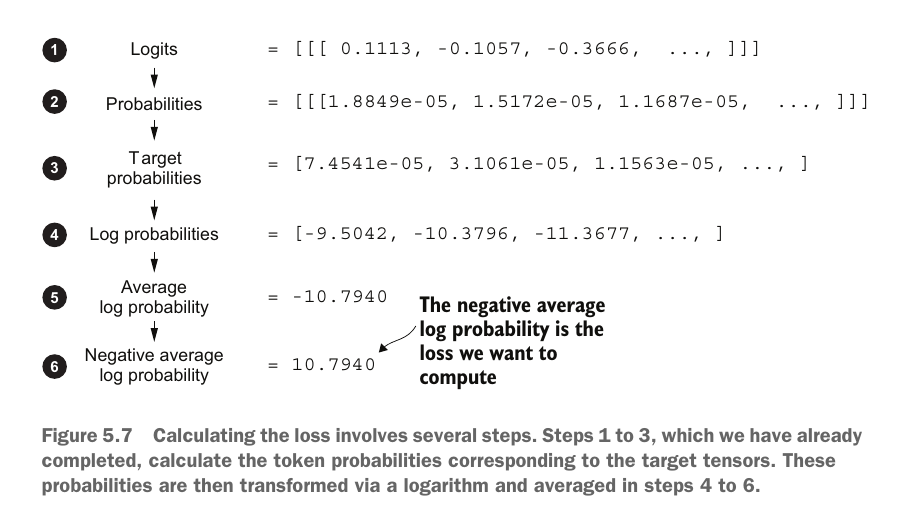
</div>

In [11]:
#       Torch's Cross Entropy Function
# - Flatten logits and targets to the required shapes for torch.nn.functional.cross_entropy:
# - logits_flat: Shape (total_tokens, vocab_size)
# - targets_flat: Shape (total_tokens,)
# - Pass flattened tensors to PyTorch's cross_entropy to compute the loss.

logits_flat = logits.flatten(0, 1) # Shape: (batch_size * seq_length, vocab_size)
targets_flat = targets.flatten() # Shape: (batch_size * seq_length)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

In [12]:
print("Flattened Logits =>", logits_flat.shape)
print("Flattened Targets =>", targets_flat.shape)

Flattened Logits => torch.Size([6, 50257])
Flattened Targets => torch.Size([6])


In [13]:
print("Loss =>", loss)

Loss => tensor(10.7940)


In [14]:
# Perplexity: A measure of how uncertain the model is when predicting the next token.
# It is calculated as perplexity = torch.exp(loss), where "loss" is the cross-entropy loss.
# Lower perplexity indicates better performance (more confident and accurate predictions).
# For example, a perplexity of 48,725 means the model's predictions are so uncertain that 
# its behavior is equivalent to randomly choosing the next token from 48,725 possible options, 
# without any knowledge or understanding of the context.

perplexity = torch.exp(loss)

In [15]:
print("Perplexity =>", perplexity)

Perplexity => tensor(48725.8203)
